/home/wren/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Feature matrix shape: (10000, 5)


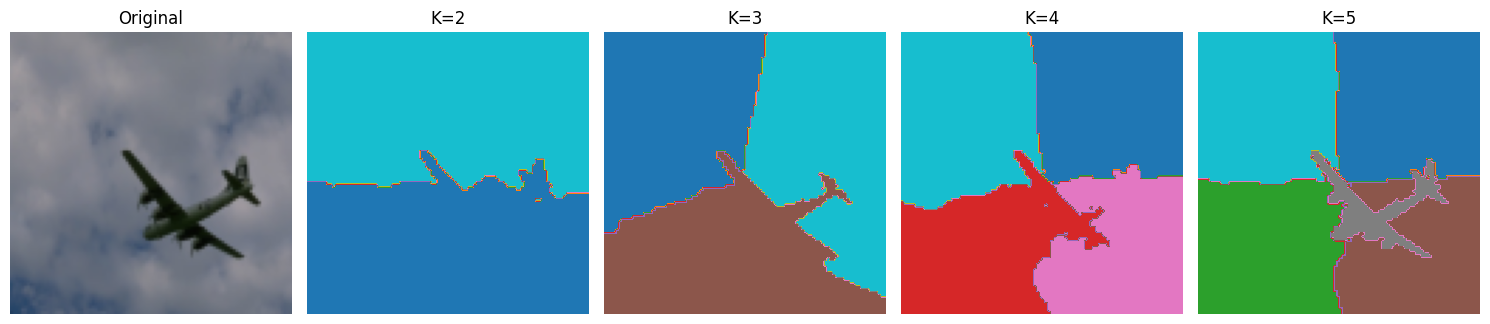

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage import io, transform


image = io.imread('../data/image1.jpg')
image = transform.resize(
    image, (100, 100), preserve_range=True).astype(np.uint8)


rows, cols, channels = image.shape

r_coords, c_coords = np.meshgrid(
    np.arange(rows), np.arange(cols), indexing='ij')

r_flat = r_coords.reshape(-1, 1)
c_flat = c_coords.reshape(-1, 1)
color_flat = image.reshape(-1, 3)

r_norm = r_flat / rows
c_norm = c_flat / cols

color_norm = color_flat / 255.0

features = np.hstack((r_norm, c_norm, color_norm))

print(f"Feature matrix shape: {features.shape}")

K_values = [2, 3, 4, 5]

plt.figure(figsize=(15, 5))

plt.subplot(1, len(K_values) + 1, 1)
plt.imshow(image)
plt.title("Original")
plt.axis('off')

for i, k in enumerate(K_values):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features)

    segmented_image = labels.reshape(rows, cols)

    plt.subplot(1, len(K_values) + 1, i + 2)
    plt.imshow(segmented_image, cmap='tab10')
    plt.title(f"K={k}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Running GMM (EM Algorithm) with K=2...
Running GMM (EM Algorithm) with K=3...
Running GMM (EM Algorithm) with K=4...
Running GMM (EM Algorithm) with K=5...


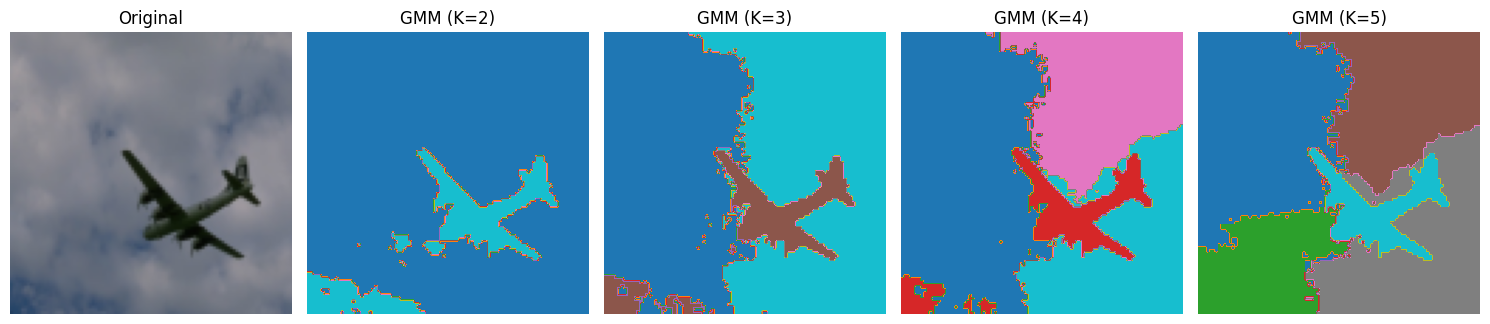

In [2]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np


K_values = [2, 3, 4, 5]

plt.figure(figsize=(15, 5))

plt.subplot(1, len(K_values) + 1, 1)
plt.imshow(image)
plt.title("Original")
plt.axis('off')

for i, k in enumerate(K_values):
    print(f"Running GMM (EM Algorithm) with K={k}...")
    # Q what is GMM model?
    gmm = GaussianMixture(
        n_components=k, random_state=42, covariance_type='full')

    gmm.fit(features)

    labels = gmm.predict(features)

    segmented_image = labels.reshape(rows, cols)

    plt.subplot(1, len(K_values) + 1, i + 2)
    plt.imshow(segmented_image, cmap='tab10')  # High contrast colormap
    plt.title(f"GMM (K={k})")
    plt.axis('off')

plt.tight_layout()
plt.show()